# 02 — Three-layer encoding framework

Full implementation of the three-layer framework on KV279 mvt.1.

In [ ]:
import sys
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.patches as mpatches
import partitura as pt, warnings
warnings.filterwarnings('ignore')
from layers import (extract_pedal_events, build_score_to_perf_map, build_beat_grid,
                    layer2_descriptors, layer3_labels, beat_unit_from_timesig_str)

DATASET  = 'path to Batik-plays-Mozart dataset directory (https://github.com/huispaty/batik_plays_mozart)'
MOVEMENT = 'kv279_1'
TIMESIG  = '4/4'

LABEL_COLORS = {
    'rhythmic':       '#4CAF50',
    'anticipatory':   '#FF9800',
    'pedaled-legato': '#2196F3',
    'half-pedal':     '#9C27B0',
    'touch':          '#00BCD4',
    'other':          '#90A4AE',
}

In [16]:
perf, alignment, score = pt.load_match(
    f'{DATASET}/match/{MOVEMENT}.match', create_score=True)
sna = score.note_array(); pna = perf.note_array(); pp = perf.performedparts[0]
cc64  = sorted([c for c in pp.controls if c['number']==64], key=lambda c: c['time'])
t_raw = np.array([c['time']  for c in cc64])
v_raw = np.array([c['value'] for c in cc64]) / 127.0

bu = beat_unit_from_timesig_str(TIMESIG)
q2t = build_score_to_perf_map(sna, pna, alignment)
beat_qs, beat_ts = build_beat_grid(sna, q2t, beat_unit=bu)

events = extract_pedal_events(pp.controls, threshold=10)
layer2_descriptors(events, beat_qs, beat_ts, sna, pna, alignment, q2t, rh_only=True)
layer3_labels(events)
print(f'{MOVEMENT}: {len(events)} pedal events  (AR computed from RH voices only)')

kv279_1: 240 pedal events  (AR computed from RH voices only)


## Layer I — Pedal event segmentation

Events: 240  |  mean: 0.51s  median: 0.44s


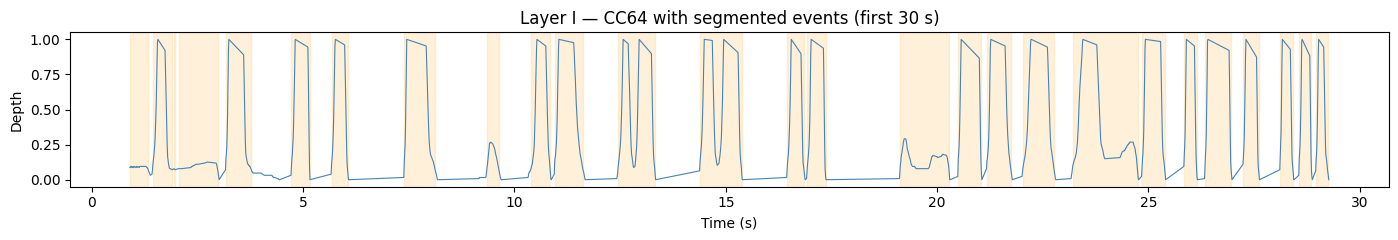

In [17]:
events = extract_pedal_events(pp.controls, threshold=10)
durs = [e.offset_sec - e.onset_sec for e in events]
print(f'Events: {len(events)}  |  mean: {np.mean(durs):.2f}s  median: {np.median(durs):.2f}s')

fig, ax = plt.subplots(figsize=(14, 2.5))
mask = t_raw < 30
ax.plot(t_raw[mask], v_raw[mask], lw=0.8, color='steelblue')
for ev in events:
    if ev.onset_sec < 30:
        ax.axvspan(ev.onset_sec, min(ev.offset_sec, 30), alpha=0.15, color='orange')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Depth')
ax.set_title('Layer I — CC64 with segmented events (first 30 s)')
plt.tight_layout(); plt.show()

## Layer II — Score-aligned descriptors

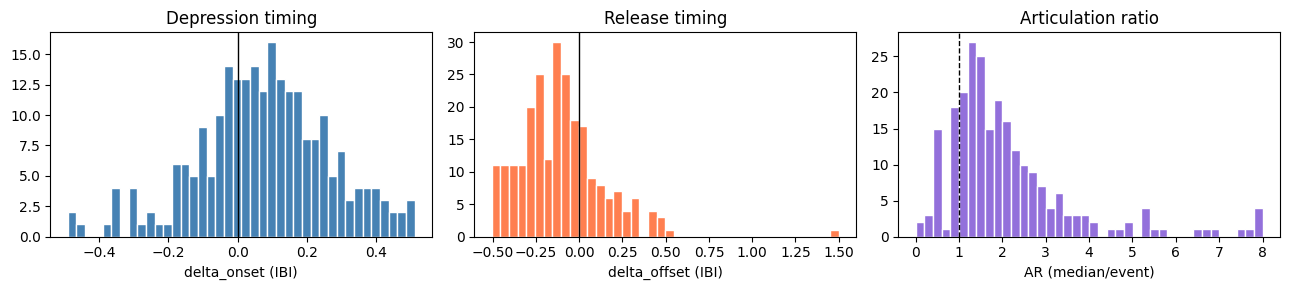

delta_onset mean=0.074  delta_offset mean=-0.103
AR median=1.74  (>1 means notes held past natural IOI)


In [18]:
layer2_descriptors(events, beat_qs, beat_ts, sna, pna, alignment, q2t)
d_on  = np.array([e.delta_onset  for e in events if e.delta_onset  is not None])
d_off = np.array([e.delta_offset for e in events if e.delta_offset is not None])
ars   = [np.median(e.ar_notes)   for e in events if e.ar_notes]

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
axes[0].hist(np.clip(d_on,  -1.5, 1.5), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='k', lw=1); axes[0].set_xlabel('delta_onset (IBI)'); axes[0].set_title('Depression timing')
axes[1].hist(np.clip(d_off, -1.5, 1.5), bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='k', lw=1); axes[1].set_xlabel('delta_offset (IBI)'); axes[1].set_title('Release timing')
axes[2].hist(np.clip(ars, 0, 8), bins=40, color='mediumpurple', edgecolor='white')
axes[2].axvline(1, color='k', lw=1, ls='--'); axes[2].set_xlabel('AR (median/event)'); axes[2].set_title('Articulation ratio')
plt.tight_layout(); plt.show()
print(f'delta_onset mean={d_on.mean():.3f}  delta_offset mean={d_off.mean():.3f}')
print(f'AR median={np.median(ars):.2f}  (>1 means notes held past natural IOI)')

## Layer III — Semantic labels

In [19]:
layer3_labels(events)
from collections import Counter
label_counts = Counter(lbl for e in events for lbl in e.labels)
print('Label distribution:')
for lbl, cnt in label_counts.most_common():
    print(f'  {lbl:20s} {cnt:4d}  ({100*cnt/len(events):.1f}%)')

Label distribution:
  rhythmic              192  (80.0%)
  pedaled-legato         83  (34.6%)
  half-pedal             41  (17.1%)
  anticipatory           27  (11.2%)
  touch                  10  (4.2%)
  other                   8  (3.3%)


## Corpus-wide label distribution (all 36 movements)

In [20]:
from collections import Counter, defaultdict
import os

TIMESIG_MAP = {}  # movement -> beat_unit, read from score annotation CSVs
movements = sorted([f.replace('.match','') for f in os.listdir(f'{DATASET}/match')
                    if f.endswith('.match')])

corpus_counts = Counter()
corpus_n = 0

for mv in movements:
    try:
        perf_mv, align_mv, score_mv = pt.load_match(
            f'{DATASET}/match/{mv}.match', create_score=True)
        sna_mv = score_mv.note_array()
        pna_mv = perf_mv.note_array()
        pp_mv  = perf_mv.performedparts[0]

        # get beat unit from score annotation CSV
        ann_path = f'{DATASET}/score_parts_annotated/{mv}_spart_annotated.csv'
        df_ann = pd.read_csv(ann_path)
        ts_str = df_ann['timesig'].dropna().iloc[0]
        bu_mv  = beat_unit_from_timesig_str(ts_str)

        q2t_mv = build_score_to_perf_map(sna_mv, pna_mv, align_mv)
        beat_qs_mv, beat_ts_mv = build_beat_grid(sna_mv, q2t_mv, beat_unit=bu_mv)

        evs_mv = extract_pedal_events(pp_mv.controls, threshold=10)
        layer2_descriptors(evs_mv, beat_qs_mv, beat_ts_mv, sna_mv, pna_mv, align_mv, q2t_mv)
        layer3_labels(evs_mv)

        corpus_counts.update(lbl for e in evs_mv for lbl in e.labels)
        corpus_n += len(evs_mv)
    except Exception as ex:
        print(f'  skip {mv}: {ex}')

print(f'Total events: {corpus_n}  across {len(movements)} movements')
print()
print('Label distribution:')
for lbl, cnt in corpus_counts.most_common():
    print(f'  {lbl:20s} {cnt:5d}  ({100*cnt/corpus_n:.1f}%)')

Total events: 10245  across 36 movements

Label distribution:
  rhythmic              6342  (61.9%)
  pedaled-legato        3330  (32.5%)
  anticipatory          1469  (14.3%)
  half-pedal            1209  (11.8%)
  touch                 1101  (10.7%)
  other                  657  (6.4%)


## Figure 3 — Score-aligned five-panel view

Piano roll (score context) + raw depth (I) + timing deltas and median AR for each pedal event (II) + semantic label bands (III).

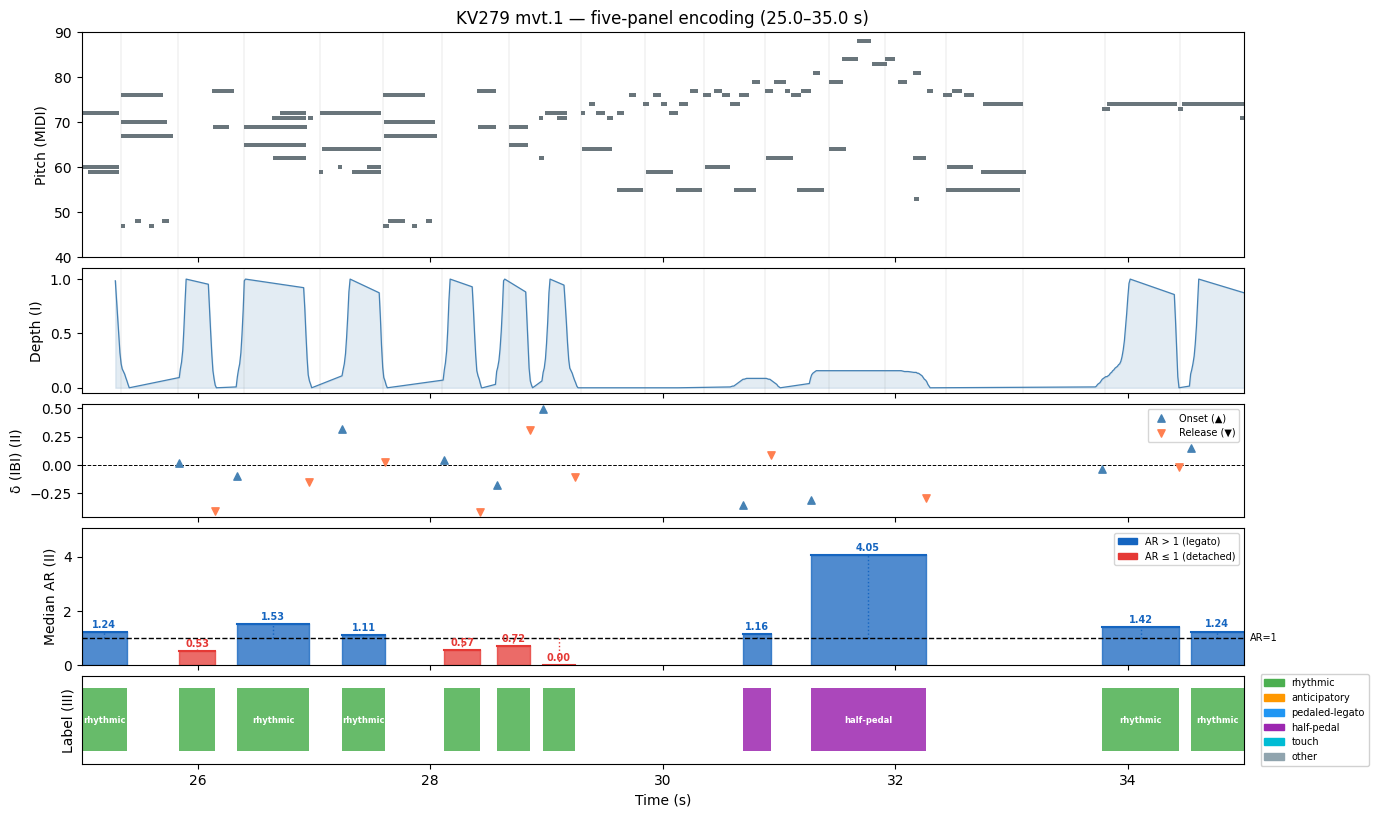

In [21]:
T_START, T_END = 25.0, 35.0

AR_THRESH = 1.0          # threshold used in layer3_labels
AR_COLOR_ABOVE = '#1565C0'   # blue  — legato (AR > 1)
AR_COLOR_BELOW = '#E53935'   # red   — detached (AR ≤ 1)

p_id2on  = {n['id']: float(n['onset_sec'])                            for n in pna}
p_id2off = {n['id']: float(n['onset_sec']) + float(n['duration_sec']) for n in pna}
p_id2pit = {n['id']: int(n['pitch'])                                  for n in pna}

fig, axes = plt.subplots(
    5, 1, figsize=(15, 9.5), sharex=True,
    gridspec_kw={'height_ratios': [1.8, 1.0, 0.9, 1.1, 0.7], 'hspace': 0.08},
)

# ── Panel 0: Piano roll ──────────────────────────────────────────────────────
ax = axes[0]
for pid, t_on in p_id2on.items():
    t_off = p_id2off[pid]; pit = p_id2pit[pid]
    if t_off < T_START or t_on > T_END: continue
    x0 = max(t_on, T_START); x1 = min(t_off, T_END)
    ax.barh(pit, x1 - x0, left=x0, height=0.85, color='#37474F', alpha=0.75)
ax.set_ylabel('Pitch (MIDI)')
ax.set_ylim(40, 90)
ax.set_title(f'KV279 mvt.1 — five-panel encoding ({T_START}–{T_END} s)')

# ── Panel 1: Layer I depth ───────────────────────────────────────────────────
ax = axes[1]
mask = (t_raw >= T_START) & (t_raw <= T_END)
ax.plot(t_raw[mask], v_raw[mask], lw=0.9, color='steelblue')
ax.fill_between(t_raw[mask], 0, v_raw[mask], color='steelblue', alpha=0.15)
ax.set_ylabel('Depth (I)'); ax.set_ylim(-0.05, 1.1)
ax.set_yticks([0, 0.5, 1.0])

# beat grid on panels 0–1
for bt in beat_ts[(beat_ts >= T_START) & (beat_ts <= T_END)]:
    axes[0].axvline(bt, color='grey', lw=0.3, alpha=0.4)
    axes[1].axvline(bt, color='grey', lw=0.3, alpha=0.4)

# ── Panel 2: Layer II timing deltas ─────────────────────────────────────────
ax = axes[2]
seen = set()
for ev in events:
    if T_START <= ev.onset_sec <= T_END and ev.delta_onset is not None:
        kw_on  = dict(label='Onset (▲)')   if 'on'  not in seen else {}
        kw_off = dict(label='Release (▼)') if 'off' not in seen else {}
        ax.scatter(ev.onset_sec,  ev.delta_onset,  marker='^', s=28,
                   color='steelblue', zorder=3, **kw_on)
        ax.scatter(ev.offset_sec, ev.delta_offset, marker='v', s=28,
                   color='coral',     zorder=3, **kw_off)
        seen.update(['on', 'off'])
ax.axhline(0, color='k', lw=0.7, ls='--')
ax.set_ylabel('δ (IBI) (II)')
ax.legend(fontsize=7, loc='upper right')

# ── Panel 3: AR per pedal event ──────────────────────────────────────────────
ax = axes[3]
ar_vals = []
for ev in events:
    if ev.offset_sec < T_START or ev.onset_sec > T_END: continue
    if not ev.ar_notes: continue
    ar_med = float(np.median(ev.ar_notes))
    ar_vals.append(ar_med)
    x0     = max(ev.onset_sec,  T_START)
    x1     = min(ev.offset_sec, T_END)
    color  = AR_COLOR_ABOVE if ar_med > AR_THRESH else AR_COLOR_BELOW

    # filled bar from 0 to ar_med, spanning event duration
    ax.fill_betweenx([0, ar_med], x0, x1, color=color, alpha=0.75)
    ax.plot([x0, x1], [ar_med, ar_med], color=color, lw=1.5)

    # stem line at event centre from threshold to ar_med
    xc = (x0 + x1) / 2
    ax.plot([xc, xc], [AR_THRESH, ar_med], color=color, lw=1.0, ls=':')

    # value label just above the top of the bar
    ax.text(xc, ar_med + 0.08, f'{ar_med:.2f}',
            ha='center', va='bottom', fontsize=7,
            color=color, fontweight='bold')

ax.axhline(AR_THRESH, color='k', lw=1.0, ls='--')
ax.text(T_END + 0.05, AR_THRESH, 'AR=1', va='center', fontsize=7, color='k')
ax.set_ylabel('Median AR (II)')
y_top = max(max(ar_vals) * 1.25, 2.8) if ar_vals else 2.8
ax.set_ylim(0, y_top)

# legend
above_patch = mpatches.Patch(color=AR_COLOR_ABOVE, label='AR > 1 (legato)')
below_patch = mpatches.Patch(color=AR_COLOR_BELOW, label='AR ≤ 1 (detached)')
ax.legend(handles=[above_patch, below_patch], fontsize=7, loc='upper right')

# ── Panel 4: Layer III labels ─────────────────────────────────────────────────
ax = axes[4]
ax.set_ylim(0, 1); ax.set_yticks([])
for ev in events:
    if ev.offset_sec < T_START or ev.onset_sec > T_END: continue
    x0 = max(ev.onset_sec, T_START); x1 = min(ev.offset_sec, T_END)
    primary = ev.labels[0] if ev.labels else 'other'
    ax.barh(0.5, x1 - x0, left=x0, height=0.72,
            color=LABEL_COLORS.get(primary, '#90A4AE'), alpha=0.85)
    if x1 - x0 > 0.35:
        ax.text((x0+x1)/2, 0.5, primary, ha='center', va='center',
                fontsize=6, color='white', fontweight='bold')
ax.set_ylabel('Label (III)'); ax.set_xlabel('Time (s)')
patches = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 0.5), loc='center left',
          fontsize=7, ncol=1, framealpha=0.9)

axes[0].set_xlim(T_START, T_END)
plt.tight_layout()
import os; os.makedirs('figures', exist_ok=True)
fig.savefig('figures/kv279_5panel_25_35s.png', dpi=600, bbox_inches='tight')
plt.show()